In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

## Hamiltonian Simulation with Trotterization

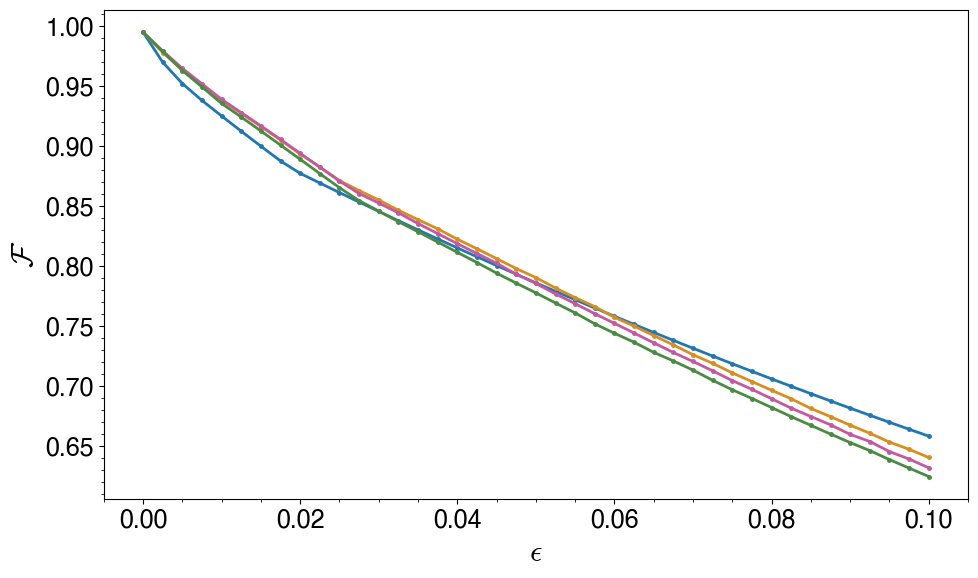

In [4]:
# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 18          # Tick labels
mpl.rcParams['ytick.labelsize'] = 18
# ==========================================================================
plt.figure(figsize=(10, 6))


custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']
# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, color= color, label=f'nqpa={nqpa}', marker='.', markersize=5, linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\mathcal{F}$")
plt.tight_layout()
# plt.legend()
plt.savefig('aer_trotter_estimation/big_k=2.pdf', bbox_inches='tight')

plt.show()
plt.close()

## Global Depolarization

## Panel 6 — Theory (SI)

Placeholder for supplemental theoretical plots.


## Panel 7 — Rydberg (SI)

Placeholder for supplemental Rydberg plots.


## Panel 8 — Experiments (SI)

Placeholder for supplemental experimental comparison plots.
